<a href="https://colab.research.google.com/github/Jenny5789/crop-image-classification/blob/main/notebooks/development/crop_classifier_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import sys

print("Python:", sys.executable)
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

Python: C:\Users\AISW_203_103\anaconda3\python.exe
TensorFlow: 2.21.0
GPU: []


# ===================================
# 1부: 데이터 준비 및 탐색
# ===================================

AI Hub "노지 작물 질병 진단 이미지" 데이터셋에서 고추, 배추, 오이 3종의
정상 이미지를 대상으로 프로젝트를 진행함. 원본 데이터의 규모를 확인하고,
학습에 사용할 이미지를 작물별로 균등하게 샘플링하여 별도 폴더로 정리함.
이후 각 작물의 샘플 이미지를 직접 시각화하여 데이터의 특성을 확인함.

In [ ]:
import os

raw_path = r"C:\Users\AISW_203_103\Desktop\crop-classifier\data\raw"

for split in ["Training", "Validation"]:
    for crop in ["고추", "배추", "오이"]:
        folder = os.path.join(raw_path, split, f"[원천]{crop}_0.정상")
        if os.path.exists(folder):
            count = len(os.listdir(folder))
            print(f"{split} - {crop}: {count}장")
        else:
            print(f"{split} - {crop}: 폴더를 찾을 수 없음 (경로 확인 필요)")

Training - 고추: 1595장
Training - 배추: 825장
Training - 오이: 623장
Validation - 고추: 1110장
Validation - 배추: 1183장
Validation - 오이: 1604장


In [ ]:
import os
import random
import shutil

raw_path = r"C:\Users\AISW_203_103\Desktop\crop-classifier\data\raw"
processed_path = r"C:\Users\AISW_203_103\Desktop\crop-classifier\data\processed"

# 혹시 이전에 만든 processed 폴더가 있다면 깨끗하게 초기화
if os.path.exists(processed_path):
    shutil.rmtree(processed_path)

crop_map = {
    "고추": "pepper",
    "배추": "cabbage",
    "오이": "cucumber"
}

# split별 목표 장수: Train은 많이, Validation은 적게
sample_counts = {
    "Training": 600,
    "Validation": 150
}
split_name_map = {
    "Training": "train",
    "Validation": "val"
}
# 같은 조건으로 다시 실행했을 때, 동일한 샘플을 선택하기 위한 seed 고정
random.seed(42)

for split_kor, n_target in sample_counts.items():
    split_eng = split_name_map[split_kor]
    print(f"[{split_kor}] 목표: 작물당 {n_target}장")

    for crop_kor, crop_eng in crop_map.items():
        src_folder = os.path.join(raw_path, split_kor, f"[원천]{crop_kor}_0.정상")
        dst_folder = os.path.join(processed_path, split_eng, crop_eng)

        os.makedirs(dst_folder, exist_ok=True)


        all_files = sorted(os.listdir(src_folder))
        n = min(n_target, len(all_files))  # 혹시 부족하면 있는 만큼만
        selected_files = random.sample(all_files, n)

        for fname in selected_files:
            shutil.copy2(os.path.join(src_folder, fname), os.path.join(dst_folder, fname))

        print(f"  {crop_kor}: {n}장 복사 완료 -> {dst_folder}")
    print()

print("전체 완료!")

[Training] 목표: 작물당 600장
  고추: 600장 복사 완료 -> C:\Users\AISW_203_103\Desktop\crop-classifier\data\processed\train\pepper
  배추: 600장 복사 완료 -> C:\Users\AISW_203_103\Desktop\crop-classifier\data\processed\train\cabbage
  오이: 600장 복사 완료 -> C:\Users\AISW_203_103\Desktop\crop-classifier\data\processed\train\cucumber

[Validation] 목표: 작물당 150장
  고추: 150장 복사 완료 -> C:\Users\AISW_203_103\Desktop\crop-classifier\data\processed\val\pepper
  배추: 150장 복사 완료 -> C:\Users\AISW_203_103\Desktop\crop-classifier\data\processed\val\cabbage
  오이: 150장 복사 완료 -> C:\Users\AISW_203_103\Desktop\crop-classifier\data\processed\val\cucumber

전체 완료!


고추 이미지 크기: (4032, 3024), 모드: RGB
배추 이미지 크기: (3024, 4032), 모드: RGB
오이 이미지 크기: (4032, 3024), 모드: RGB


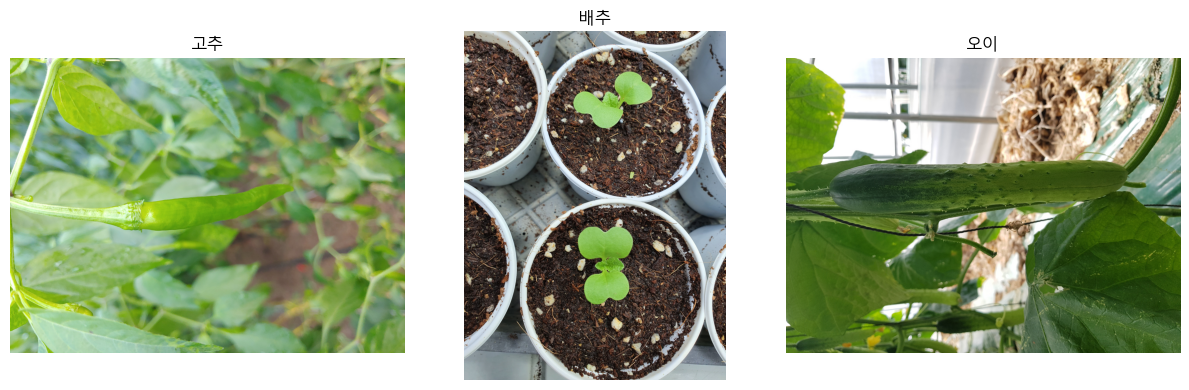

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

processed_path = r"C:\Users\AISW_203_103\Desktop\crop-classifier\data\processed"


# 각 클래스별로 이미지 하나씩 확인
crops = ["pepper", "cabbage", "cucumber"]
crop_names_kor = {"pepper": "고추", "cabbage": "배추", "cucumber": "오이"}

plt.figure(figsize=(12,4))

for i, crop in enumerate(crops):
    folder = os.path.join(processed_path, "train", crop)
    sample_file = os.listdir(folder)[0]  # 첫 번째 이미지
    img_path = os.path.join(folder, sample_file)

    img = Image.open(img_path)
    print(f"{crop_names_kor[crop]} 이미지 크기: {img.size}, 모드: {img.mode}")

    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.title(crop_names_kor[crop])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow import keras
from tensorflow.keras import models, layers

IMG_SIZE = 128
BATCH_SIZE = 32

train_ds = keras.utils.image_dataset_from_directory(
    r"C:\Users\AISW_203_103\Desktop\crop-classifier\data\processed\train",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int'
)

val_ds = keras.utils.image_dataset_from_directory(
    r"C:\Users\AISW_203_103\Desktop\crop-classifier\data\processed\val",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int'
)

class_names = train_ds.class_names
print("클래스 목록:", class_names)

Found 1800 files belonging to 3 classes.
Found 450 files belonging to 3 classes.
클래스 목록: ['cabbage', 'cucumber', 'pepper']


In [ ]:
import time
import pandas as pd

experiment_results = []

def run_experiment(name, model, train_ds, val_ds, epochs=15, verbose=1):
    start_time = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=verbose)
    elapsed = time.time() - start_time

    experiment_results.append({
        "실험명": name,
        "epochs": epochs,
        "총_파라미터": model.count_params(),
        "train_acc": round(history.history['accuracy'][-1], 4),
        "val_acc": round(history.history['val_accuracy'][-1], 4),
        "train_loss": round(history.history['loss'][-1], 4),
        "val_loss": round(history.history['val_loss'][-1], 4),
        "학습시간_초": round(elapsed, 1)
    })
    print(f"[기록 완료] {name}")
     # 이후 Accuracy/Loss 그래프 등에 사용하기 위해 history 반환
    return history

In [ ]:
model_baseline = models.Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])
model_baseline.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_baseline = run_experiment("baseline (Conv3, Dropout0.3, epoch15)", model_baseline, train_ds, val_ds, epochs=15)

Epoch 1/15


C:\Users\AISW_203_103\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


57/57 ━━━━━━━━━━━━━━━━━━━━ 28s 461ms/step - accuracy: 0.5278 - loss: 0.9636 - val_accuracy: 0.5889 - val_loss: 0.8960
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 23s 409ms/step - accuracy: 0.8300 - loss: 0.4532 - val_accuracy: 0.6133 - val_loss: 1.2179
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 24s 417ms/step - accuracy: 0.9039 - loss: 0.2731 - val_accuracy: 0.5444 - val_loss: 1.1251
Epoch 4/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 24s 412ms/step - accuracy: 0.9306 - loss: 0.1890 - val_accuracy: 0.5111 - val_loss: 1.5455
Epoch 5/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 23s 399ms/step - accuracy: 0.9544 - loss: 0.1362 - val_accuracy: 0.6467 - val_loss: 1.3295
Epoch 6/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 23s 405ms/step - accuracy: 0.9761 - loss: 0.0693 - val_accuracy: 0.6356 - val_loss: 1.5134
Epoch 7/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 23s 399ms/step - accuracy: 0.9906 - loss: 0.0331 - val_accuracy: 0.6867 - val_loss: 1.5086
Epoch 8/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 23s 398ms/step - accuracy: 0.9772 - loss: 0.0660 - val_accuracy: 0.646

## 실험 1: Baseline 결과 분석

- train accuracy: 0.5278 → 0.9994
- val_accuracy: 0.5889 → 0.6667
- val_accuracy는 약 0.5~0.6대에서 변동하며, train accuracy만큼 상승하지 않음
- val_loss: 0.8960 → 2.5658로 전반적으로 증가
- **결론**: 학습이 진행되면서 train accuracy는 거의 1.0까지 상승했지만, validation 성능은 그만큼 개선되지 않았고 val_loss도 증가함 → **과적합(Overfitting) 발생**

In [ ]:
model_aug = models.Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])
model_aug.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_aug = run_experiment("data_augmentation_only", model_aug, train_ds, val_ds, epochs=15)

Epoch 1/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 29s 474ms/step - accuracy: 0.5250 - loss: 0.9126 - val_accuracy: 0.4556 - val_loss: 1.0252
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 27s 467ms/step - accuracy: 0.7206 - loss: 0.6582 - val_accuracy: 0.5711 - val_loss: 1.1909
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 35s 613ms/step - accuracy: 0.8061 - loss: 0.4981 - val_accuracy: 0.5600 - val_loss: 1.3186
Epoch 4/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 32s 553ms/step - accuracy: 0.8822 - loss: 0.3306 - val_accuracy: 0.5911 - val_loss: 2.1313
Epoch 5/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 39s 682ms/step - accuracy: 0.9128 - loss: 0.2340 - val_accuracy: 0.5689 - val_loss: 2.9170
Epoch 6/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 37s 648ms/step - accuracy: 0.9167 - loss: 0.2466 - val_accuracy: 0.6578 - val_loss: 1.7924
Epoch 7/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 34s 596ms/step - accuracy: 0.9422 - loss: 0.1937 - val_accuracy: 0.6200 - val_loss: 2.3360
Epoch 8/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 45s 675ms/step - accuracy: 0.9433 - loss: 0.1624 - val_accu

## 실험 2: Data Augmentation 적용 결과 분석

- train accuracy: 0.5250 → 0.9622 (Baseline보다 최종 train accuracy가 낮아짐)
- val_accuracy: 0.4556 → 0.6511 (학습 중 약 0.46~0.66 수준에서 변동)
- val_loss: 1.0252 → 2.9766으로 전반적으로 증가
- **Baseline과 비교**:
  - train_acc: 0.9994 → 0.9622 (하락)
  - val_acc: 0.6667 → 0.6511 (하락)
  - val_loss: 2.5658 → 2.9766 (증가)
- **결론**: Data Augmentation 적용 후 train accuracy는 Baseline보다 낮아졌지만, val_accuracy는 개선되지 않았고 val_loss도 더 높아짐. 이번 실험에서는 Data Augmentation만으로 과적합이 개선되었다고 보기 어려움.

In [ ]:
model_dropout = models.Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),   # 0.3 -> 0.5로 변경 (이것만 바뀜)
    layers.Dense(3, activation='softmax')
])
model_dropout.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_dropout = run_experiment("dropout_0.5_only", model_dropout, train_ds, val_ds, epochs=15)

Epoch 1/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 34s 571ms/step - accuracy: 0.6356 - loss: 0.7906 - val_accuracy: 0.5511 - val_loss: 1.0096
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 30s 529ms/step - accuracy: 0.8706 - loss: 0.3633 - val_accuracy: 0.6244 - val_loss: 1.2146
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 31s 540ms/step - accuracy: 0.9100 - loss: 0.2702 - val_accuracy: 0.5156 - val_loss: 1.5194
Epoch 4/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 32s 556ms/step - accuracy: 0.9183 - loss: 0.2555 - val_accuracy: 0.6244 - val_loss: 1.2459
Epoch 5/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 35s 620ms/step - accuracy: 0.9383 - loss: 0.1742 - val_accuracy: 0.6244 - val_loss: 1.6479
Epoch 6/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 29s 494ms/step - accuracy: 0.9550 - loss: 0.1339 - val_accuracy: 0.6600 - val_loss: 1.3537
Epoch 7/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 36s 638ms/step - accuracy: 0.9694 - loss: 0.1027 - val_accuracy: 0.6556 - val_loss: 1.3810
Epoch 8/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 38s 660ms/step - accuracy: 0.9756 - loss: 0.0840 - val_accu

## 실험 3: Dropout 강화(0.5) 적용 결과 분석

- train accuracy: 0.6356 → 0.9817
- val_accuracy: 0.5511 → 0.6711
- val_loss: 1.0096 → 2.0525로 전반적으로 증가
- **Baseline과 비교**:
  - train_acc: 0.9994 → 0.9817 (하락)
  - val_acc: 0.6667 → 0.6711 (소폭 상승)
  - val_loss: 2.5658 → 2.0525 (감소)
- **결론**: Dropout 비율을 0.3에서 0.5로 높인 결과, train accuracy는 Baseline보다 낮아졌고 val_accuracy는 소폭 상승했으며 val_loss는 감소함. 이번 실험에서는 Dropout 강화 후 validation 성능이 Baseline보다 개선됨. 다만 train-validation 성능 차이가 여전히 커 과적합이 완전히 해소된 것은 아님.

In [ ]:
model_combined = models.Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')
])
model_combined.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_combined = run_experiment("data_aug + dropout_0.5", model_combined, train_ds, val_ds, epochs=15)

Epoch 1/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 34s 559ms/step - accuracy: 0.5356 - loss: 0.9128 - val_accuracy: 0.5378 - val_loss: 0.9224
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 31s 548ms/step - accuracy: 0.7078 - loss: 0.6832 - val_accuracy: 0.5711 - val_loss: 1.1167
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 32s 553ms/step - accuracy: 0.7822 - loss: 0.5505 - val_accuracy: 0.5378 - val_loss: 1.3261
Epoch 4/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 32s 555ms/step - accuracy: 0.8094 - loss: 0.4870 - val_accuracy: 0.5778 - val_loss: 1.2011
Epoch 5/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 31s 546ms/step - accuracy: 0.8672 - loss: 0.3620 - val_accuracy: 0.5889 - val_loss: 1.8598
Epoch 6/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 33s 571ms/step - accuracy: 0.9017 - loss: 0.2875 - val_accuracy: 0.5311 - val_loss: 2.3028
Epoch 7/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 33s 572ms/step - accuracy: 0.9194 - loss: 0.2434 - val_accuracy: 0.5556 - val_loss: 3.3912
Epoch 8/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 33s 573ms/step - accuracy: 0.9161 - loss: 0.2348 - val_accu

## 실험 4: Data Augmentation + Dropout 0.5 동시 적용 결과 분석

- train accuracy: 0.5356 → 0.9422
- val_accuracy: 0.5378 → 0.5756 (학습 중 약 0.49~0.63 수준에서 변동)
- val_loss: 0.9224 → 4.1595로 전반적으로 증가
- **Baseline과 비교**:
  - train_acc: 0.9994 → 0.9422 (하락)
  - val_acc: 0.6667 → 0.5756 (하락)
  - val_loss: 2.5658 → 4.1595 (증가)
- **실험 2(Data Augmentation), 실험 3(Dropout 0.5)과 비교**:
  - 실험 2: val_acc 0.6511 / val_loss 2.9766
  - 실험 3: val_acc 0.6711 / val_loss 2.0525
  - 실험 4: val_acc 0.5756 / val_loss 4.1595
- **결론**: Data Augmentation과 Dropout 0.5를 함께 적용했지만 Baseline보다 val_accuracy가 낮고 val_loss가 크게 높아짐. 또한 Dropout 0.5만 적용한 실험 3보다 validation 성능이 낮아, 이번 실험에서는 두 기법의 동시 적용이 추가적인 성능 개선으로 이어지지 않음.

In [ ]:
model_simple = models.Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Conv2D(16, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.GlobalAveragePooling2D(),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')
])
model_simple.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model_simple.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)              │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 126, 126, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 63, 63, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 61, 61, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 30, 30, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 28, 28, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 32)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,491 (60.51 KB)

 Trainable params: 15,491 (60.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_simple = run_experiment("simplified_model (GAP, filter down, dropout0.5)", model_simple, train_ds, val_ds, epochs=15)

Epoch 1/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 29s 485ms/step - accuracy: 0.4228 - loss: 1.0433 - val_accuracy: 0.4222 - val_loss: 1.0251
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 27s 474ms/step - accuracy: 0.5956 - loss: 0.8766 - val_accuracy: 0.4733 - val_loss: 0.9866
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 27s 467ms/step - accuracy: 0.7283 - loss: 0.7139 - val_accuracy: 0.5822 - val_loss: 1.0359
Epoch 4/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 28s 484ms/step - accuracy: 0.7717 - loss: 0.5992 - val_accuracy: 0.5689 - val_loss: 1.0485
Epoch 5/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 27s 472ms/step - accuracy: 0.8061 - loss: 0.5671 - val_accuracy: 0.5289 - val_loss: 0.9911
Epoch 6/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 28s 497ms/step - accuracy: 0.8250 - loss: 0.5067 - val_accuracy: 0.5289 - val_loss: 0.9973
Epoch 7/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 30s 522ms/step - accuracy: 0.8450 - loss: 0.4518 - val_accuracy: 0.6156 - val_loss: 0.9817
Epoch 8/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 30s 528ms/step - accuracy: 0.8572 - loss: 0.4011 - val_accu

## 실험 5: 모델 구조 단순화 (필터 수 축소 + GlobalAveragePooling2D) 결과 분석

- train accuracy: 0.4228 → 0.9200
- val_accuracy: 0.4222 → 0.6511 (최고 0.6800)
- val_loss: 1.0251 → 1.0065
- 모델 파라미터 수: 859,395개 → 15,491개로 감소
- **Baseline과 비교**:
  - train_acc: 0.9994 → 0.9200 (하락)
  - val_acc: 0.6667 → 0.6511 (소폭 하락)
  - val_loss: 2.5658 → 1.0065 (감소)
  - train-val accuracy 격차: 33.27%p → 26.89%p로 축소
- **결론**: 필터 수를 줄이고 GlobalAveragePooling2D를 적용해 모델 구조를 단순화한 결과, Baseline보다 최종 val_accuracy는 소폭 낮아졌지만 val_loss와 train-val 정확도 격차는 크게 감소함. 또한 학습 중 최고 val_accuracy는 0.6800으로 Baseline의 최고 0.6867과 유사한 수준을 유지함. 이번 실험에서는 모델 복잡도를 크게 줄이면서도 validation 정확도를 크게 잃지 않고, 과적합 정도를 완화하는 방향을 확인함.

In [ ]:
model_simple_aug = models.Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.Conv2D(16, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.GlobalAveragePooling2D(),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')
])
model_simple_aug.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_simple_aug = run_experiment("simplified_model + data_aug", model_simple_aug, train_ds, val_ds, epochs=15)

Epoch 1/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 34s 545ms/step - accuracy: 0.4150 - loss: 1.0614 - val_accuracy: 0.4089 - val_loss: 1.0876
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 27s 475ms/step - accuracy: 0.5622 - loss: 0.9077 - val_accuracy: 0.4111 - val_loss: 1.1267
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 25s 430ms/step - accuracy: 0.6350 - loss: 0.8207 - val_accuracy: 0.5400 - val_loss: 1.1299
Epoch 4/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 24s 413ms/step - accuracy: 0.6806 - loss: 0.7412 - val_accuracy: 0.5711 - val_loss: 1.0788
Epoch 5/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 25s 446ms/step - accuracy: 0.6989 - loss: 0.7167 - val_accuracy: 0.5511 - val_loss: 1.0873
Epoch 6/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 30s 519ms/step - accuracy: 0.7111 - loss: 0.6962 - val_accuracy: 0.5822 - val_loss: 1.0346
Epoch 7/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 30s 524ms/step - accuracy: 0.7450 - loss: 0.6681 - val_accuracy: 0.5622 - val_loss: 1.1011
Epoch 8/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 30s 522ms/step - accuracy: 0.7522 - loss: 0.6195 - val_accu

## 실험 6: 단순화 모델 + Data Augmentation 결과 분석

- train accuracy: 0.4150 → 0.8578
- val_accuracy: 0.4089 → 0.6222 (학습 중 최고 0.6222)
- val_loss: 1.0876 → 1.0469
- **실험 5(단순화 모델)와 비교**:
  - train_acc: 0.9200 → 0.8578 (하락)
  - val_acc: 0.6511 → 0.6222 (하락)
  - val_loss: 1.0065 → 1.0469 (소폭 증가)
- **결론**: 단순화 모델에 Data Augmentation을 추가한 결과, 실험 5보다 train accuracy와 val_accuracy가 낮아졌고 val_loss도 소폭 높아짐. 이번 실험에서는 단순화 모델에 Data Augmentation을 추가하는 것이 validation 성능 개선으로 이어지지 않았으며, 실험 5의 단순화 모델이 더 나은 결과를 보임.

In [ ]:
model_simple2 = models.Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Conv2D(16, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(16, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(16, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.GlobalAveragePooling2D(),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')
])
model_simple2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_simple2.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_6 (Rescaling)              │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_18 (Conv2D)                   │ (None, 126, 126, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_18 (MaxPooling2D)      │ (None, 63, 63, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_19 (Conv2D)                   │ (None, 61, 61, 16)          │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_19 (MaxPooling2D)      │ (None, 30, 30, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_20 (Conv2D)                   │ (None, 28, 28, 16)          │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_20 (MaxPooling2D)      │ (None, 14, 14, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 16)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 16)                  │             272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 3)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,411 (21.14 KB)

 Trainable params: 5,411 (21.14 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_simple2 = run_experiment("simplified_model_v2 (16-16-16 filters, Dense16)", model_simple2, train_ds, val_ds, epochs=15)

Epoch 1/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 34s 570ms/step - accuracy: 0.4583 - loss: 1.0405 - val_accuracy: 0.5600 - val_loss: 0.9465
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 21s 369ms/step - accuracy: 0.5444 - loss: 0.9106 - val_accuracy: 0.5422 - val_loss: 0.8832
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 21s 360ms/step - accuracy: 0.5950 - loss: 0.8320 - val_accuracy: 0.5244 - val_loss: 0.8947
Epoch 4/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 20s 352ms/step - accuracy: 0.6533 - loss: 0.7740 - val_accuracy: 0.6067 - val_loss: 0.8392
Epoch 5/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 20s 357ms/step - accuracy: 0.6394 - loss: 0.7805 - val_accuracy: 0.5756 - val_loss: 0.8496
Epoch 6/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 20s 348ms/step - accuracy: 0.6722 - loss: 0.7409 - val_accuracy: 0.5511 - val_loss: 0.8091
Epoch 7/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 20s 349ms/step - accuracy: 0.7550 - loss: 0.6106 - val_accuracy: 0.5133 - val_loss: 0.9601
Epoch 8/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 21s 365ms/step - accuracy: 0.7806 - loss: 0.5620 - val_accu

## 실험 7: 모델 추가 단순화 (필터 16-16-16, Dense16) 결과 분석

- train accuracy: 0.4583 → 0.8544
- val_accuracy: 0.5600 → 0.6667 (최고 0.6667)
- val_loss: 0.9465 → 0.8253
- **실험 5(필터 16-32-32, Dense32)와 비교**:
  - 파라미터 수: 15,491 → 5,411 (약 65% 감소)
  - train_acc: 0.9200 → 0.8544 (하락)
  - val_acc: 0.6511 → 0.6667 (상승)
  - val_loss: 1.0065 → 0.8253 (감소)
  - train-val accuracy 격차: 26.89%p → 18.77%p로 축소
- **결론**: 실험 5보다 모델을 추가로 단순화한 결과, 파라미터 수와 val_loss, train-val 정확도 격차가 감소했고 val_accuracy도 소폭 상승함. 이번 실험에서는 모델 크기를 더 줄였음에도 validation 성능이 유지되는 수준을 넘어 오히려 일부 개선되었으며, 추가 단순화가 현재 데이터에서는 더 적절한 방향일 가능성을 확인함.

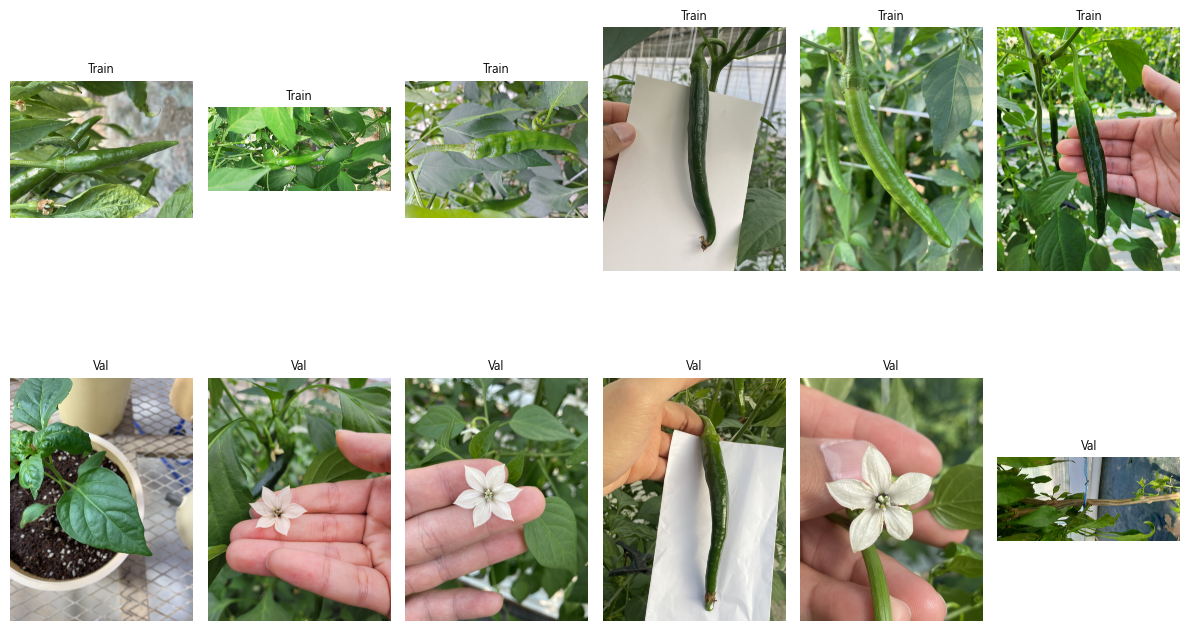

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import random

folder = r"C:\Users\AISW_203_103\Desktop\crop-classifier\data\raw\Training\[원천]고추_0.정상"
val_folder = r"C:\Users\AISW_203_103\Desktop\crop-classifier\data\raw\Validation\[원천]고추_0.정상"

random.seed(2)

train_files = random.sample(os.listdir(folder), 6)
val_files = random.sample(os.listdir(val_folder), 6)

plt.figure(figsize=(12,8))
for i, fname in enumerate(train_files):
    img = Image.open(os.path.join(folder, fname))
    plt.subplot(2,6,i+1)
    plt.imshow(img)
    plt.title("Train", fontsize=9)
    plt.axis('off')

for i, fname in enumerate(val_files):
    img = Image.open(os.path.join(val_folder, fname))
    plt.subplot(2,6,i+7)
    plt.imshow(img)
    plt.title("Val", fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

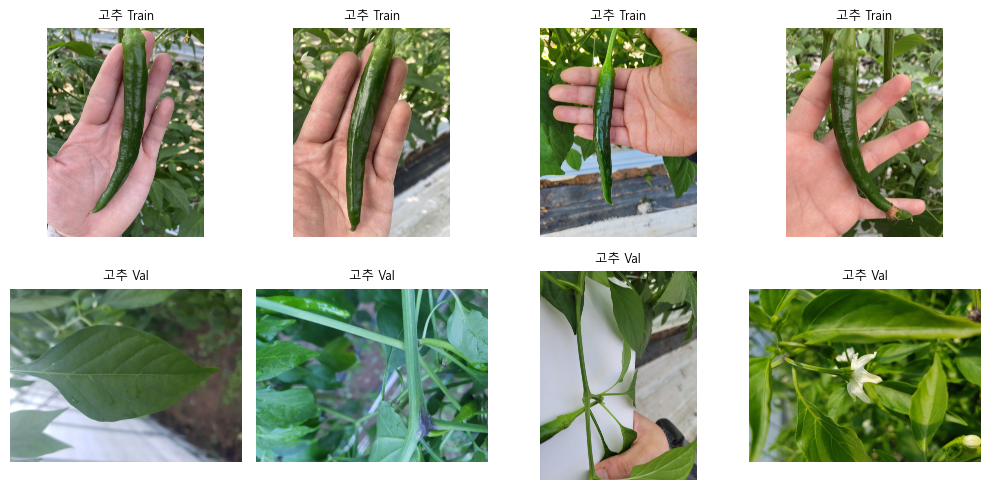

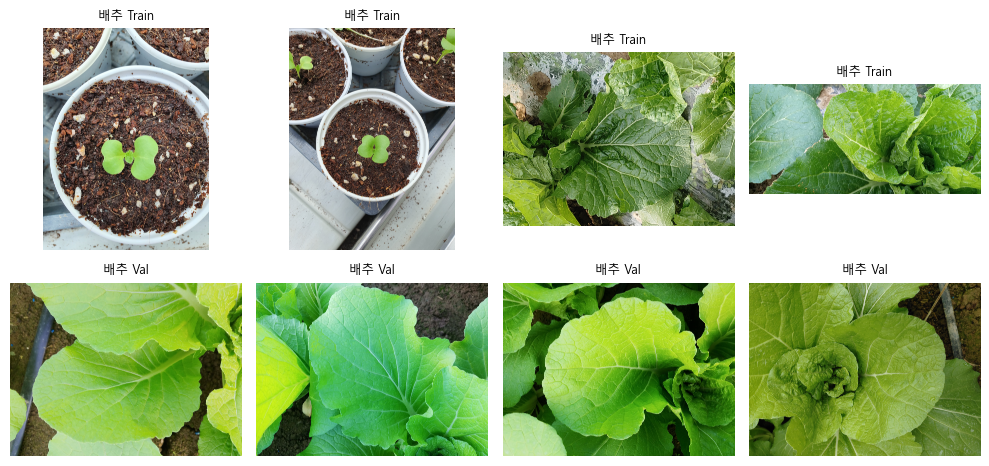

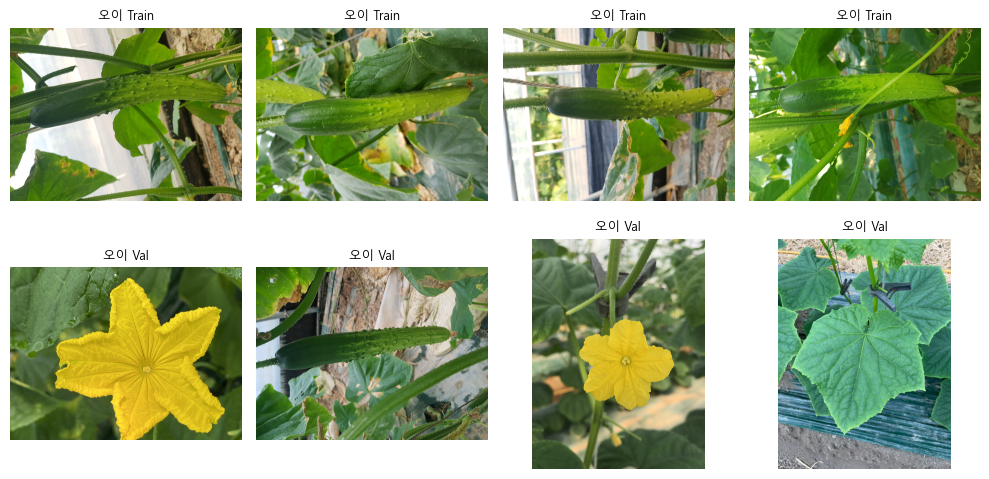

In [ ]:
crops_info = [
    ("고추", r"[원천]고추_0.정상"),
    ("배추", r"[원천]배추_0.정상"),
    ("오이", r"[원천]오이_0.정상")
]

for crop_name, folder_name in crops_info:
    train_path = f"C:\\Users\\AISW_203_103\\Desktop\\crop-classifier\\data\\raw\\Training\\{folder_name}"
    val_path = f"C:\\Users\\AISW_203_103\\Desktop\\crop-classifier\\data\\raw\\Validation\\{folder_name}"

    train_sample = random.sample(os.listdir(train_path), 4)
    val_sample = random.sample(os.listdir(val_path), 4)

    plt.figure(figsize=(10,5))
    for i, fname in enumerate(train_sample):
        img = Image.open(os.path.join(train_path, fname))
        plt.subplot(2,4,i+1)
        plt.imshow(img)
        plt.title(f"{crop_name} Train", fontsize=9)
        plt.axis('off')
    for i, fname in enumerate(val_sample):
        img = Image.open(os.path.join(val_path, fname))
        plt.subplot(2,4,i+5)
        plt.imshow(img)
        plt.title(f"{crop_name} Val", fontsize=9)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

## Training/Validation 데이터 구성 차이 확인

- 모델 구조를 단순화한 실험 5와 7에서도 val_accuracy가 60%대에 머물러, 모델 구조 외에 데이터 분할의 영향 가능성을 확인함
- 원본 Training/Validation 이미지를 직접 샘플링하여 비교한 결과, 동일 클래스에서도 피사체와 생육 단계의 차이가 관찰됨
  - 고추: Training은 열매 중심, Validation은 잎·줄기·꽃이 포함된 이미지가 관찰됨
  - 배추: 어린 묘와 성장한 배추 등 생육 단계의 차이가 관찰됨
  - 오이: Training은 열매 중심, Validation은 꽃·잎이 포함된 이미지가 관찰됨
- 샘플 이미지에서 확인한 차이만으로 데이터 분할이 성능 저하의 원인이라고 단정하지 않고, 재분할 후 동일 조건에서 성능 변화를 비교하기로 함
- **후속 조치**: 기존 Training과 Validation 데이터를 통합한 뒤 무작위로 재분할하여 `data/reprocessed`를 구성하고, 동일한 모델 조건에서 재검증

==================================================================================================